
# WMT25 Translation Error-Correction Dataset — Demo

This notebook demonstrates the `data.py` build script that produces the **WMT25 Translation Error-Correction Dataset**, in two components:

1. **`wmt25_task3_natural`** — official WMT25 Task 3 test-set rows (English source, an MT system's hypothesis output, and CometKiwi-derived QE error spans with severity `minor`/`major`/`critical`), across 6 language pairs (`en-{zh_CN, cs_CZ, ja_JP, is_IS, ru_RU, uk_UA}`).
2. **`injected_error_augmentation`** — rows built by programmatically *corrupting* held-out human-translated reference text (from `google/wmt24pp`) along 4 controlled invariant categories: `named_entity_swap`, `number_unit_date_alteration`, `negation_polarity_flip`, `quantifier_substitution`. Each corrupted row carries the clean original text, the corrupted text, and the exact character-offset span that was changed — so a downstream error-detector's precision/recall against ground truth is directly computable.

The full build script also assigns each language-pair / category cell into `experimental_pool` vs `checker_validation_heldout` folds, kept disjoint.

This demo runs the **same corruption and fold-assignment logic** as the original script, on a small hand-picked sample (`mini_demo_data.json`) instead of the full raw WMT25/wmt24pp downloads, so it finishes in seconds while remaining recognizably the same code.


In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru -- the original script's only dependency, NOT pre-installed on Colab
_pip('loguru==0.7.3')

# matplotlib -- pre-installed on Colab, install locally at Colab's exact version
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import ast
import csv
import json
import random
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path

from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# extra imports for this notebook's data-loading + visualization cells
import urllib.request
import os
import matplotlib.pyplot as plt


## Load the demo data

`mini_demo_data.json` is a small hand-picked sample of the two *raw inputs* the real script reads from disk:
`wmt25_natural_rows` (a few WMT25 Task 3 TSV rows per language pair, already carrying QE-flagged spans) and
`wmt24pp_by_lang` (a few clean `wmt24pp` reference rows per language, picked so each corruption category has at
least one example that fires). It is fetched from GitHub with a local-file fallback so this notebook also runs
standalone.


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-e9bf19-isolating-what-fixes-failed-span-editing/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")


In [4]:
data = load_data()
print("wmt25_natural_rows:", len(data["wmt25_natural_rows"]))
print("wmt24pp_by_lang:", {lang: len(rows) for lang, rows in data["wmt24pp_by_lang"].items()})


wmt25_natural_rows: 18
wmt24pp_by_lang: {'cs_CZ': 8, 'is_IS': 6, 'ja_JP': 8, 'ru_RU': 8, 'uk_UA': 7, 'zh_CN': 8}


## Config

All tunable parameters from the original script, gathered here. `MAX_PER_CELL` is the per (language_pair,
category) cap the real script uses to balance the injected component (130 in the full run); `HELDOUT_FRAC` is
the held-out fold fraction. Both are unchanged from the original script's values since they are already small
constants, not scale knobs — what actually shrinks this demo is the size of `mini_demo_data.json` itself.


In [5]:
RNG = random.Random(20260901)  # fixed seed, same as the original script

LANG_CONFIGS = {
    "cs_CZ": "en-cs_CZ",
    "is_IS": "en-is_IS",
    "ja_JP": "en-ja_JP",
    "ru_RU": "en-ru_RU",
    "uk_UA": "en-uk_UA",
    "zh_CN": "en-zh_CN",
}

HELDOUT_FRAC = 0.18

MAX_PER_CELL = 130  # cap per (language_pair, category) for balance, not raw volume
# the mini demo sample is far smaller than this cap in every cell, so it never binds here


## Category construction resources

Per-language cue lists, regexes, and stopword sets used by the corruption functions below — copied verbatim
from the original script. These implement the language-specific guards the summary describes: word-boundary
matching for space-delimited languages, explicit accented-letter classes (not naive Unicode ranges), a
"negation fires only if exactly one marker is present" rule for negative-concord languages, etc.


In [6]:
NEGATION_CUES = {
    "cs_CZ": ["nikdy", "žádný", "žádná", "žádné", "nic", "nikoho", "není", "nejsou",
              "nemá", "nemají", "nebude", "nechce", "neví", "nemůže", "neudělal"],
    "is_IS": ["ekki", "aldrei", "enginn", "engin", "ekkert", "hvorki"],
    "ja_JP": ["ない", "ません", "なかった", "ありません", "できない"],
    "ru_RU": ["не", "нет", "никогда", "ничего", "никто", "нельзя"],
    "uk_UA": ["не", "ні", "ніколи", "нічого", "ніхто", "не можна"],
    "zh_CN": ["不", "没有", "没", "从不", "无法", "并非"],
}

QUANTIFIER_PAIRS = {
    "cs_CZ": [("všichni", "někteří"), ("všechny", "některé"), ("vždy", "nikdy"),
              ("nikdy", "vždy"), ("nikdo", "někdo"), ("nic", "něco"), ("občas", "nikdy")],
    "is_IS": [("allir", "sumir"), ("allar", "sumar"), ("alltaf", "aldrei"),
              ("aldrei", "alltaf"), ("enginn", "einhver"), ("ekkert", "eitthvað")],
    "ja_JP": [("すべて", "いくつか"), ("すべての", "一部の"), ("いつも", "決して"),
              ("誰も", "誰か"), ("常に", "時々")],
    "ru_RU": [("все", "некоторые"), ("всегда", "никогда"), ("никогда", "всегда"),
              ("никто", "кто-то"), ("ничего", "что-то"), ("каждый", "некоторые")],
    "uk_UA": [("усі", "деякі"), ("всі", "деякі"), ("завжди", "ніколи"),
              ("ніколи", "завжди"), ("ніхто", "хтось"), ("кожен", "деякі")],
    "zh_CN": [("所有", "一些"), ("总是", "从不"), ("从不", "总是"),
              ("每个", "某些"), ("从来没有", "有时"), ("没有人", "有人")],
}

# Explicit accented-letter case pairs per language (raw code-point ranges like
# A-Za-z do NOT extend correctly to Latin Extended accented characters, whose
# upper/lower forms are not laid out in a single contiguous range -- a naive
# [A-ZÀ-Ž] class matches stray lowercase letters like Icelandic "í").
CS_UPPER, CS_LOWER = "ÁČĎÉĚÍŇÓŘŠŤÚŮÝŽ", "áčďéěíňóřšťúůýž"
IS_UPPER, IS_LOWER = "ÁÐÉÍÓÚÝÞÆÖ", "áðéíóúýþæö"
LATIN_ENTITY_RE = re.compile(
    rf"[A-Z{CS_UPPER}{IS_UPPER}][a-z{CS_LOWER}{IS_LOWER}]+"
    rf"(?:\s[A-Z{CS_UPPER}{IS_UPPER}][a-z{CS_LOWER}{IS_LOWER}]+){{0,2}}"
)
CYRILLIC_ENTITY_RE = re.compile(r"[А-ЯЁІЇЄҐ][а-яёіїєґ'-]+(?:\s[А-ЯЁІЇЄҐ][а-яёіїєґ'-]+){0,2}")
YEAR_RE = re.compile(r"(?<![@\w])(1[89]\d{2}|20\d{2})(?!\w)")
NUMBER_RE = re.compile(r"(?<![@\w.])\d+(?:[.,]\d+)?(?!\w)")

STOP_WORDS_LATIN = {"The", "This", "That", "These", "Those", "A", "An", "It", "He", "She",
                     "They", "We", "You", "I"}

# Common closed-class words that get capitalized whenever they start a
# sentence/clause -- without a real NER model these are indistinguishable
# from proper nouns by capitalization alone, so they must be excluded by
# name. Demonstratives, pronouns, conjunctions, frequent adverbs.
ENTITY_STOP_WORDS = {
    "cs_CZ": {"Tato", "Tento", "Tyto", "Toto", "Ten", "Ta", "To", "Tento", "Tímto",
              "Ale", "Avšak", "Proto", "Podle", "Když", "Pokud", "Nicméně", "Také",
              "Proč", "Jak", "Kdy", "Kde", "Co", "Kdo", "My", "Vy", "Oni", "Ona",
              "On", "Jeho", "Její", "Jejich", "Náš", "Váš", "Ještě", "Už", "Teď",
              "Poté", "Potom", "Přesto", "Protože", "Takže", "Jenže", "Jinak"},
    "is_IS": {"Þetta", "Þessi", "Þessar", "Þessu", "Þessum", "Sá", "Sú", "Það", "Þau",
              "En", "Því", "Samt", "Samkvæmt", "Ef", "Þegar", "Hvers", "Hvernig",
              "Hvenær", "Hvar", "Hvað", "Hver", "Við", "Þið", "Þeir", "Hún", "Hann",
              "Hans", "Hennar", "Þeirra", "Okkar", "Ykkar", "Enn", "Núna", "Síðan"},
    "ru_RU": {"Это", "Этот", "Эта", "Эти", "Тот", "Та", "То", "Те", "Но", "Однако",
              "Поэтому", "Согласно", "Если", "Когда", "Почему", "Как", "Где", "Что",
              "Кто", "Мы", "Вы", "Они", "Она", "Он", "Его", "Её", "Их", "Наш", "Ваш",
              "Ещё", "Уже", "Теперь", "Потом", "Затем", "Тем", "Так", "Также"},
    "uk_UA": {"Це", "Цей", "Ця", "Ці", "Той", "Та", "То", "Ті", "Але", "Однак",
              "Тому", "Згідно", "Якщо", "Коли", "Чому", "Як", "Де", "Що", "Хто",
              "Ми", "Ви", "Вони", "Вона", "Він", "Його", "Її", "Їхній", "Наш", "Ваш",
              "Ще", "Вже", "Тепер", "Потім", "Отже", "Також"},
}


## Entity extraction + distractor pools

`extract_entities` finds capitalized (or Cyrillic-capitalized) candidate proper nouns per language, filtered by
the stopwords above. `build_entity_pools` then collects same-language distractor candidates across all rows,
keeping only ones that are *rare* corpus-wide (a real proper noun recurs rarely; a capitalized function word
recurs often) — this pool is what `corrupt_entity` swaps names from.


In [7]:
def _is_sentence_boundary_capitalization(text: str, start: int) -> bool:
    """True if `start` is right after sentence-ending punctuation (or the
    string start) -- i.e. the capitalization is just orthographic sentence-
    casing, not a signal of a proper noun."""
    prefix = text[:start].rstrip()
    if not prefix:
        return True
    return prefix[-1] in ".!?…”’\""


def _entity_matches(text: str, lang: str) -> list[re.Match]:
    stop = ENTITY_STOP_WORDS.get(lang, set()) | STOP_WORDS_LATIN
    out = []
    for m in entity_regex_for_lang(lang).finditer(text):
        if m.start() == 0 or len(m.group()) < 4:
            continue
        if m.group() in stop:
            continue
        if _is_sentence_boundary_capitalization(text, m.start()):
            continue
        out.append(m)
    return out


def entity_regex_for_lang(lang: str) -> re.Pattern:
    if lang in ("cs_CZ", "is_IS"):
        return LATIN_ENTITY_RE
    if lang in ("ru_RU", "uk_UA"):
        return CYRILLIC_ENTITY_RE
    return LATIN_ENTITY_RE  # zh_CN / ja_JP: catches embedded Latin-script entities only


def extract_entities(text: str, lang: str) -> list[str]:
    return [m.group() for m in _entity_matches(text, lang)]


ENTITY_MAX_CORPUS_FREQ = 3  # a real proper noun is rare across ~960 rows; a
# capitalization false positive (function word capitalized by clause
# position) recurs far more often -- this is a corpus-frequency check in
# the same spirit as the plan's "collides with an existing natural
# occurrence" discard rule, generalized to catch stopword-heuristic misses
# no hand-built per-language stoplist would fully cover.


def build_entity_pools(rows_by_lang: dict) -> dict:
    """First pass: collect same-language distractor entity candidates from clean
    text, keeping only candidates that are RARE corpus-wide (proper-noun-like)."""
    freq = defaultdict(Counter)
    for lang, rows in rows_by_lang.items():
        for r in rows:
            for ent in extract_entities(r["target"], lang):
                freq[lang][ent] += 1
    pools = {}
    for lang, counts in freq.items():
        pools[lang] = sorted(w for w, c in counts.items() if c <= ENTITY_MAX_CORPUS_FREQ)
        logger.info(
            f"entity distractor pool[{lang}] = {len(pools[lang])} candidates "
            f"(of {len(counts)} raw capitalized candidates before frequency filter)"
        )
    return {"pool": pools, "freq": freq}


## Corruption functions

The core of the `injected_error_augmentation` component: four functions, one per invariant category, each
returning `None` (nothing to corrupt) or `(corrupted_text, original_span, corrupted_span, (start, end))` using
character offsets into the original clean text. `corrupt_negation` only fires when a sentence carries exactly
one negation marker (Slavic/Czech negative-concord languages allow several to co-occur, so removing just one
would not reliably flip polarity), and `_cue_occurrences` matches on word boundaries for space-delimited
languages but as substrings for `zh_CN`/`ja_JP`, which have no inter-word spaces.


In [8]:
def corrupt_entity(text: str, lang: str, pool: list[str], freq: Counter) -> tuple | None:
    if not pool:
        return None
    ents = [m for m in _entity_matches(text, lang) if freq.get(m.group(), 0) <= ENTITY_MAX_CORPUS_FREQ]
    if not ents:
        return None
    m = RNG.choice(ents)
    original = m.group()
    candidates = [e for e in pool if e != original]
    RNG.shuffle(candidates)
    for distractor in candidates[:8]:
        # discard if the distractor already occurs naturally elsewhere in the sentence
        rest = text[:m.start()] + text[m.end():]
        if distractor in rest:
            continue
        corrupted_text = text[: m.start()] + distractor + text[m.end():]
        return corrupted_text, original, distractor, (m.start(), m.end())
    return None


def _perturb_number_str(num_str: str) -> str | None:
    digits = [c for c in num_str if c.isdigit()]
    if not digits:
        return None
    first_digit_idx = next(i for i, c in enumerate(num_str) if c.isdigit())
    d = int(num_str[first_digit_idx])
    new_d = d + 1 if d < 9 else d - 1
    if first_digit_idx == 0 and new_d == 0 and len(digits) > 1:
        new_d = 1
    return num_str[:first_digit_idx] + str(new_d) + num_str[first_digit_idx + 1:]


def corrupt_number(text: str, lang: str) -> tuple | None:
    m = YEAR_RE.search(text)
    if m:
        new_val = _perturb_number_str(m.group())
        if new_val and new_val != m.group():
            corrupted_text = text[: m.start()] + new_val + text[m.end():]
            return corrupted_text, m.group(), new_val, (m.start(), m.end())
    m = NUMBER_RE.search(text)
    if m:
        new_val = _perturb_number_str(m.group())
        if new_val and new_val != m.group():
            corrupted_text = text[: m.start()] + new_val + text[m.end():]
            return corrupted_text, m.group(), new_val, (m.start(), m.end())
    return None


def corrupt_negation(text: str, lang: str) -> tuple | None:
    cues = NEGATION_CUES.get(lang, [])
    # Slavic/Czech/Ukrainian and colloquial Chinese use negative concord --
    # multiple negation markers can co-occur in one clause without cancelling
    # each other (e.g. cs "Nikdy nic není snadné" = triple negation, still
    # negative after removing one marker). Only flip when exactly one marker
    # total is present, so removing/inserting it is guaranteed to change polarity.
    total_hits = sum(len(_cue_occurrences(text, cue, lang)) for cue in cues)
    if total_hits != 1:
        return None
    for cue in cues:
        matches = _cue_occurrences(text, cue, lang)
        if not matches:
            continue
        idx, end = matches[0].start(), matches[0].end()
        # collapse one adjacent space if present, to keep the sentence well-formed
        new_end = end + 1 if end < len(text) and text[end] == " " else end
        new_start = idx - 1 if new_end == end and idx > 0 and text[idx - 1] == " " else idx
        corrupted_text = text[:new_start] + text[new_end:]
        return corrupted_text, text[idx:end], "", (idx, end)
    return None


def corrupt_quantifier(text: str, lang: str) -> tuple | None:
    pairs = QUANTIFIER_PAIRS.get(lang, [])
    for orig, repl in pairs:
        matches = _cue_occurrences(text, orig, lang)
        if not matches:
            continue
        idx, end = matches[0].start(), matches[0].end()
        corrupted_text = text[:idx] + repl + text[end:]
        return corrupted_text, orig, repl, (idx, end)
    return None


CATEGORY_FUNCS = {
    "named_entity_swap": corrupt_entity,
    "number_unit_date_alteration": corrupt_number,
    "negation_polarity_flip": corrupt_negation,
    "quantifier_substitution": corrupt_quantifier,
}

# cs_CZ/is_IS/ru_RU/uk_UA are space-delimited -- match cue/quantifier tokens on
# word boundaries so e.g. Cyrillic "не" does not fire inside "нервах", or
# Czech "nic" inside "nich". zh_CN/ja_JP have no inter-word spaces, so cues
# are matched as substrings (a single Han/kana negation morpheme is itself
# the semantic unit there, unlike a Latin/Cyrillic root).
WORD_BOUNDARY_LANGS = {"cs_CZ", "is_IS", "ru_RU", "uk_UA"}


def _cue_occurrences(text: str, cue: str, lang: str) -> list[re.Match]:
    if lang in WORD_BOUNDARY_LANGS:
        return list(re.finditer(rf"\b{re.escape(cue)}\b", text))
    return [m for m in re.finditer(re.escape(cue), text)]


## Natural component (WMT25 Task 3)

`load_wmt25_natural` normalizes the official test-set rows into the schema's `input`/`output`/`metadata_*`
fields, parsing the QE-flagged error spans. `assign_natural_folds` then splits each language pair into
`experimental_pool` / `checker_validation_heldout`, stratified per language pair.

*(Original change: the real script reads `wmt25_task3_combined_test_set.tsv` off disk with `csv.DictReader`;
here the same row shape is already provided as `data["wmt25_natural_rows"]`, so `load_wmt25_natural` is adapted
to iterate that list directly instead of opening a file.)*


In [9]:
def load_wmt25_natural(rows: list[dict]) -> list[dict]:
    # NOTE: original opened WMT25_TSV with csv.DictReader; `rows` here is that
    # same list-of-dicts shape, already loaded from `data["wmt25_natural_rows"]`.
    logger.info(f"loaded {len(rows)} natural WMT25 Task3 rows")

    examples = []
    for r in rows:
        lang = r["target_lang"]
        lp = f"en-{lang}"
        try:
            spans = ast.literal_eval(r["error_spans"]) if r["error_spans"] else []
        except (ValueError, SyntaxError):
            spans = []
        examples.append(
            {
                "input": r["source_segment"],
                "output": r["hypothesis_segment"],
                "metadata_language_pair": lp,
                "metadata_domain": r["domain_name"],
                "metadata_qe_flagged_spans": spans,
                "metadata_human_error_annotations": None,
                "metadata_provenance": "natural",
                "metadata_invariant_category": None,
                "metadata_source_dataset": "wmt-conference/wmt25-mteval:wmt25_task3_combined_test_set",
                "metadata_doc_id": r["doc_id"],
                "metadata_segment_id": r["segment_id"],
                "metadata_system_id": r["system_id"],
                "metadata_overall_qe_score": float(r["overall"]) if r["overall"] else None,
                "metadata_notes": (
                    "QE error spans are the CometKiwi-derived spans released pre-scoring "
                    "(character offsets into output/hypothesis_segment, severity in "
                    "{minor,major,critical}). No post-hoc human MQM severity/type gold "
                    "layer matching the findings-paper Table 15 is publicly released as of "
                    "this build (post_edit column empty for all 6000 rows) -- treat "
                    "qe_flagged_spans as the operational localization signal, per the "
                    "dataset_search_plan's documented fallback."
                ),
            }
        )
    return examples


def assign_natural_folds(examples: list[dict]) -> None:
    by_lp = defaultdict(list)
    for ex in examples:
        by_lp[ex["metadata_language_pair"]].append(ex)
    for lp, group in by_lp.items():
        RNG.shuffle(group)
        n_heldout = max(1, round(len(group) * HELDOUT_FRAC))
        for ex in group[:n_heldout]:
            ex["metadata_fold"] = "checker_validation_heldout"
        for ex in group[n_heldout:]:
            ex["metadata_fold"] = "experimental_pool"
        logger.info(f"natural[{lp}]: {len(group)} total, {n_heldout} heldout")


natural_examples = load_wmt25_natural(data["wmt25_natural_rows"])
assign_natural_folds(natural_examples)


11:32:27|INFO   |loaded 18 natural WMT25 Task3 rows


11:32:27|INFO   |natural[en-zh_CN]: 3 total, 1 heldout


11:32:27|INFO   |natural[en-cs_CZ]: 3 total, 1 heldout


11:32:27|INFO   |natural[en-ja_JP]: 3 total, 1 heldout


11:32:27|INFO   |natural[en-ru_RU]: 3 total, 1 heldout


11:32:27|INFO   |natural[en-uk_UA]: 3 total, 1 heldout


11:32:27|INFO   |natural[en-is_IS]: 3 total, 1 heldout


## Injected component (built from wmt24pp clean references)

`build_injected_examples` walks each language's clean reference rows and, for every invariant category still
under `MAX_PER_CELL` for that (language_pair, category) cell, tries the matching corruption function. A hit
becomes a row carrying the clean target, the corrupted text, and the exact span that changed.
`assign_injected_folds` then splits per (language_pair, category) cell the same way the natural component does
per language pair.

*(Original change: the real script's `load_wmt24pp_clean` reads `full_google_wmt24pp_{cfg}_train.json` per
language off disk and filters out `is_bad_source`/`canary` rows; here `data["wmt24pp_by_lang"]` already holds
that filtered row shape per language, so the loader is skipped and `rows_by_lang` is read straight from `data`.)*


In [10]:
def build_injected_examples(rows_by_lang: dict, pools: dict) -> list[dict]:
    examples = []
    counts = defaultdict(int)
    for lang, rows in rows_by_lang.items():
        lp = f"en-{lang}"
        shuffled = rows[:]
        RNG.shuffle(shuffled)
        for r in shuffled:
            target = r["target"]
            for category, func in CATEGORY_FUNCS.items():
                cell = (lp, category)
                if counts[cell] >= MAX_PER_CELL:
                    continue
                if category == "named_entity_swap":
                    result = func(target, lang, pools["pool"].get(lang, []), pools["freq"].get(lang, Counter()))
                else:
                    result = func(target, lang)
                if result is None:
                    continue
                corrupted_text, orig_span, corrupted_span, (start, end) = result
                if corrupted_text.strip() == target.strip():
                    continue
                examples.append(
                    {
                        "input": r["source"],
                        "output": corrupted_text,
                        "metadata_language_pair": lp,
                        "metadata_domain": r["domain"],
                        "metadata_qe_flagged_spans": None,
                        "metadata_human_error_annotations": None,
                        "metadata_provenance": "injected",
                        "metadata_invariant_category": category,
                        "metadata_source_dataset": "google/wmt24pp",
                        "metadata_doc_id": r["document_id"],
                        "metadata_segment_id": r["segment_id"],
                        "metadata_system_id": None,
                        "metadata_overall_qe_score": None,
                        "metadata_clean_target_text": target,
                        "metadata_original_span": orig_span,
                        "metadata_corrupted_span": corrupted_span,
                        "metadata_span_offsets": {"start": start, "end": end},
                        "metadata_notes": (
                            f"Programmatically corrupted from a held-out wmt24pp "
                            f"(google/wmt24pp, WMT24++ human post-edited target, "
                            f"a corpus wholly disjoint from the WMT25 Task 3 test set "
                            f"used for the natural component) clean reference. Category="
                            f"{category}. Ground truth = metadata_clean_target_text."
                        ),
                    }
                )
                counts[cell] += 1
    for cell, n in sorted(counts.items()):
        logger.info(f"injected[{cell[0]}][{cell[1]}] = {n}")
    logger.info(f"total injected examples: {len(examples)}")
    return examples


def assign_injected_folds(examples: list[dict]) -> None:
    by_cell = defaultdict(list)
    for ex in examples:
        by_cell[(ex["metadata_language_pair"], ex["metadata_invariant_category"])].append(ex)
    for cell, group in by_cell.items():
        RNG.shuffle(group)
        n_heldout = max(1, round(len(group) * HELDOUT_FRAC))
        for ex in group[:n_heldout]:
            ex["metadata_fold"] = "checker_validation_heldout"
        for ex in group[n_heldout:]:
            ex["metadata_fold"] = "experimental_pool"


rows_by_lang = data["wmt24pp_by_lang"]
pools = build_entity_pools(rows_by_lang)
injected_examples = build_injected_examples(rows_by_lang, pools)
assign_injected_folds(injected_examples)


11:32:27|INFO   |entity distractor pool[cs_CZ] = 23 candidates (of 23 raw capitalized candidates before frequency filter)


11:32:27|INFO   |entity distractor pool[is_IS] = 16 candidates (of 17 raw capitalized candidates before frequency filter)


11:32:27|INFO   |entity distractor pool[ja_JP] = 6 candidates (of 6 raw capitalized candidates before frequency filter)


11:32:27|INFO   |entity distractor pool[ru_RU] = 23 candidates (of 23 raw capitalized candidates before frequency filter)


11:32:27|INFO   |entity distractor pool[uk_UA] = 17 candidates (of 18 raw capitalized candidates before frequency filter)


...

11:32:27|INFO   |injected[en-zh_CN][named_entity_swap] = 6


11:32:27|INFO   |injected[en-zh_CN][negation_polarity_flip] = 3


11:32:27|INFO   |injected[en-zh_CN][number_unit_date_alteration] = 4


11:32:27|INFO   |injected[en-zh_CN][quantifier_substitution] = 1


11:32:27|INFO   |total injected examples: 81


## Results

A few example corrupted rows (clean target → corrupted output, with the exact span changed), plus a summary
table and chart of how many rows landed in each invariant category and fold, for both components.


natural examples:  18
injected examples: 81

=== sample injected (corrupted) rows ===
[en-cs_CZ / named_entity_swap / experimental_pool]
  clean:     „Lidé koupající se v plaveckém bazénu“ z roku 2022 je jedním z uměleckých děl Vicenta Sisoa, která se budou vystavovat v galerii Tierra del Sol od 13. ledna. (foto se svolením Vicenta Sisoa)
  corrupted: „Lidé koupající se v plaveckém bazénu“ z roku 2022 je jedním z uměleckých děl Santa Monica Blvd, která se budou vystavovat v galerii Tierra del Sol od 13. ledna. (foto se svolením Vicenta Sisoa)
  span:      'Vicenta Sisoa' -> 'Santa Monica Blvd' @ {'start': 78, 'end': 91}

[en-cs_CZ / number_unit_date_alteration / experimental_pool]
  clean:     „Lidé koupající se v plaveckém bazénu“ z roku 2022 je jedním z uměleckých děl Vicenta Sisoa, která se budou vystavovat v galerii Tierra del Sol od 13. ledna. (foto se svolením Vicenta Sisoa)
  corrupted: „Lidé koupající se v plaveckém bazénu“ z roku 3022 je jedním z uměleckých děl Vicenta Sisoa, 

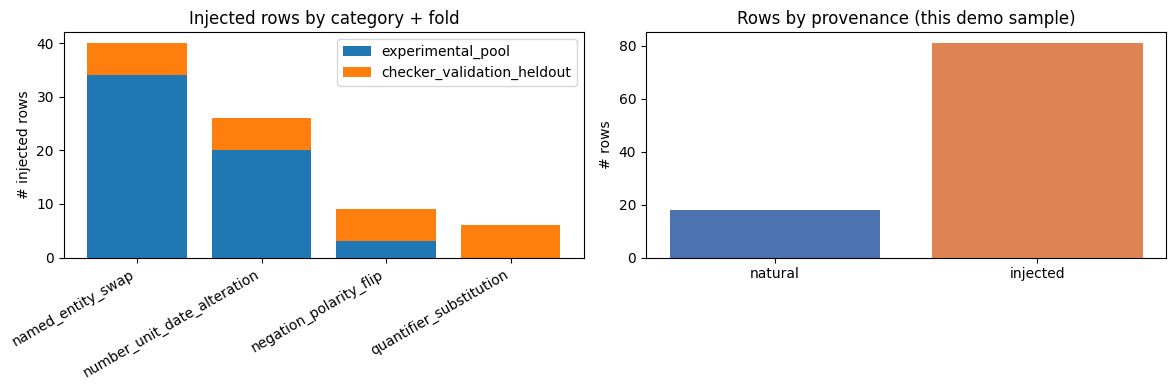

In [11]:
print(f"natural examples:  {len(natural_examples)}")
print(f"injected examples: {len(injected_examples)}")
print()
print("=== sample injected (corrupted) rows ===")
for ex in injected_examples[:5]:
    print(f"[{ex['metadata_language_pair']} / {ex['metadata_invariant_category']} / {ex['metadata_fold']}]")
    print(f"  clean:     {ex['metadata_clean_target_text']}")
    print(f"  corrupted: {ex['output']}")
    print(f"  span:      {ex['metadata_original_span']!r} -> {ex['metadata_corrupted_span']!r} "
          f"@ {ex['metadata_span_offsets']}")
    print()

print("=== sample natural (QE-flagged) row ===")
ex = natural_examples[0]
print(f"[{ex['metadata_language_pair']} / {ex['metadata_domain']} / {ex['metadata_fold']}]")
print(f"  source: {ex['input'][:150]}...")
print(f"  hypothesis: {ex['output'][:150]}...")
print(f"  qe_flagged_spans: {ex['metadata_qe_flagged_spans']}")

# --- summary table: category x fold counts for the injected component ---
cat_fold_counts = defaultdict(lambda: defaultdict(int))
for ex in injected_examples:
    cat_fold_counts[ex["metadata_invariant_category"]][ex["metadata_fold"]] += 1

categories = list(CATEGORY_FUNCS.keys())
folds = ["experimental_pool", "checker_validation_heldout"]

print("\n=== injected_error_augmentation: category x fold counts ===")
header = f"{'category':<28}" + "".join(f"{f:>26}" for f in folds)
print(header)
for cat in categories:
    row = f"{cat:<28}" + "".join(f"{cat_fold_counts[cat][f]:>26}" for f in folds)
    print(row)

# --- chart ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pool_counts = [cat_fold_counts[c]["experimental_pool"] for c in categories]
heldout_counts = [cat_fold_counts[c]["checker_validation_heldout"] for c in categories]
x = range(len(categories))
axes[0].bar(x, pool_counts, label="experimental_pool")
axes[0].bar(x, heldout_counts, bottom=pool_counts, label="checker_validation_heldout")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(categories, rotation=30, ha="right")
axes[0].set_ylabel("# injected rows")
axes[0].set_title("Injected rows by category + fold")
axes[0].legend()

by_provenance = Counter(ex["metadata_provenance"] for ex in natural_examples + injected_examples)
axes[1].bar(by_provenance.keys(), by_provenance.values(), color=["#4C72B0", "#DD8452"])
axes[1].set_ylabel("# rows")
axes[1].set_title("Rows by provenance (this demo sample)")

plt.tight_layout()
plt.show()
